## Installing libraries

In [5]:
!pip install torch torchvision torchaudio
!pip install torch-geometric
!pip install scikit-learn matplotlib networkx
!pip install ogb

## Importing all required libraries

In [6]:
import torch
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures
from torch_geometric.utils import to_networkx
from torch_geometric.nn import GCNConv, GATConv

from sklearn.metrics import accuracy_score, f1_score

In [7]:
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

set_seed(42)

In [9]:

dataset = Planetoid(
    root="data/Planetoid",
    name="Cora",
    transform=NormalizeFeatures()
)

data = dataset[0]

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
data = data.to(device)

criterion = torch.nn.CrossEntropyLoss()

Using device: cpu


In [11]:
print(dataset)

print("Number of graphs:", len(dataset))
print("Number of features:", dataset.num_node_features)
print("Number of classes:", dataset.num_classes)

print(data)

Cora()
Number of graphs: 1
Number of features: 1433
Number of classes: 7
Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


In [12]:
print("Number of nodes:", data.num_nodes)
print("Number of edges:", data.num_edges)

print("Training nodes:", data.train_mask.sum().item())
print("Validation nodes:", data.val_mask.sum().item())
print("Test nodes:", data.test_mask.sum().item())

Number of nodes: 2708
Number of edges: 10556
Training nodes: 140
Validation nodes: 500
Test nodes: 1000


In [13]:
print("Feature matrix shape:", data.x.shape)
print("Edge index shape:", data.edge_index.shape)
print("Label shape:", data.y.shape)

Feature matrix shape: torch.Size([2708, 1433])
Edge index shape: torch.Size([2, 10556])
Label shape: torch.Size([2708])


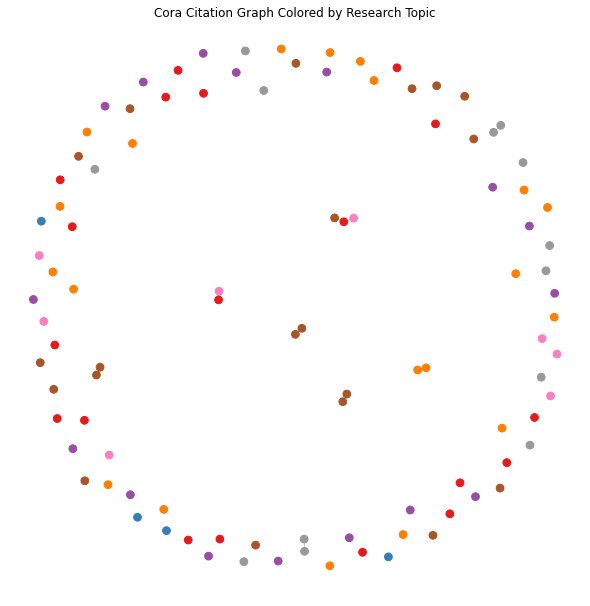

In [14]:
# Convert PyG graph to NetworkX
graph = to_networkx(data, to_undirected=True)

# Select a subset of nodes
sub_nodes = list(range(100))
subgraph = graph.subgraph(sub_nodes)

# Layout for graph drawing
pos = nx.spring_layout(subgraph, seed=42)

# Node colors based on paper topic
node_colors = data.y[:100].cpu().numpy()

plt.figure(figsize=(8,8))

nx.draw(
    subgraph,
    pos,
    node_size=60,
    node_color=node_colors,
    cmap=plt.cm.Set1,
    edge_color="gray",
    width=0.4,
    with_labels=False
)

plt.title("Cora Citation Graph Colored by Research Topic")
plt.show()

## GCN Model (Cora)

In [15]:
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

In [16]:
model = GCN(
    in_channels=dataset.num_node_features,
    hidden_channels=16,
    out_channels=dataset.num_classes
).to(device)

print(model)

GCN(
  (conv1): GCNConv(1433, 16)
  (conv2): GCNConv(16, 7)
)


In [17]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01,
    weight_decay=5e-4
)

In [18]:
criterion = torch.nn.CrossEntropyLoss()

In [19]:
def train():

    model.train()

    optimizer.zero_grad()

    out = model(data.x, data.edge_index)

    loss = criterion(
        out[data.train_mask],
        data.y[data.train_mask]
    )

    loss.backward()

    optimizer.step()

    return loss.item()

In [20]:
@torch.no_grad()
def evaluate():

    model.eval()

    out = model(data.x, data.edge_index)

    pred = out.argmax(dim=1)

    train_acc = accuracy_score(
        data.y[data.train_mask].cpu(),
        pred[data.train_mask].cpu()
    )

    val_acc = accuracy_score(
        data.y[data.val_mask].cpu(),
        pred[data.val_mask].cpu()
    )

    test_acc = accuracy_score(
        data.y[data.test_mask].cpu(),
        pred[data.test_mask].cpu()
    )

    test_f1 = f1_score(
        data.y[data.test_mask].cpu(),
        pred[data.test_mask].cpu(),
        average="macro"
    )

    return train_acc, val_acc, test_acc, test_f1

In [21]:
num_epochs = 200

train_losses = []
val_accuracies = []
test_accuracies = []

for epoch in range(1, num_epochs + 1):

    loss = train()

    train_acc, val_acc, test_acc, test_f1 = evaluate()

    train_losses.append(loss)
    val_accuracies.append(val_acc)
    test_accuracies.append(test_acc)

    if epoch % 20 == 0:

        print(
            f"Epoch {epoch:03d} | "
            f"Loss {loss:.4f} | "
            f"Val Acc {val_acc:.4f} | "
            f"Test Acc {test_acc:.4f}"
        )

Epoch 020 | Loss 1.7174 | Val Acc 0.5260 | Test Acc 0.5360
Epoch 040 | Loss 1.3281 | Val Acc 0.7040 | Test Acc 0.7030
Epoch 060 | Loss 0.9540 | Val Acc 0.7600 | Test Acc 0.7720
Epoch 080 | Loss 0.6925 | Val Acc 0.7760 | Test Acc 0.7900
Epoch 100 | Loss 0.5591 | Val Acc 0.7660 | Test Acc 0.7950
Epoch 120 | Loss 0.4700 | Val Acc 0.7740 | Test Acc 0.8020
Epoch 140 | Loss 0.4071 | Val Acc 0.7780 | Test Acc 0.8010
Epoch 160 | Loss 0.3849 | Val Acc 0.7780 | Test Acc 0.8010
Epoch 180 | Loss 0.3435 | Val Acc 0.7780 | Test Acc 0.8020
Epoch 200 | Loss 0.3223 | Val Acc 0.7800 | Test Acc 0.7990


In [22]:
gcn_train_acc, gcn_val_acc, gcn_test_acc, gcn_test_f1 = evaluate()

print("\nFinal GCN Results")
print(f"Train Accuracy: {gcn_train_acc:.4f}")
print(f"Validation Accuracy: {gcn_val_acc:.4f}")
print(f"Test Accuracy: {gcn_test_acc:.4f}")
print(f"Test Macro F1-score: {gcn_test_f1:.4f}")


Final GCN Results
Train Accuracy: 1.0000
Validation Accuracy: 0.7800
Test Accuracy: 0.7990
Test Macro F1-score: 0.7878


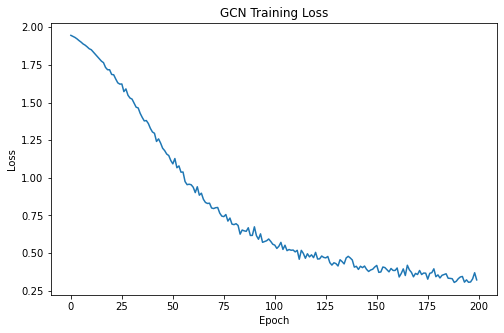

In [23]:
plt.figure(figsize=(8,5))

plt.plot(train_losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("GCN Training Loss")

plt.show()

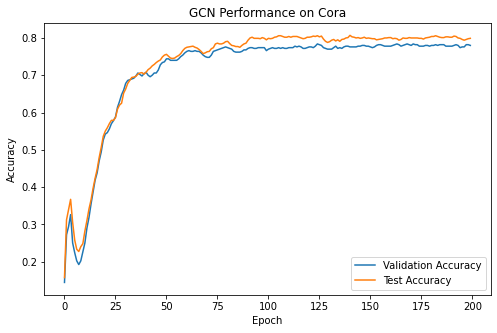

In [24]:
plt.figure(figsize=(8,5))

plt.plot(val_accuracies, label="Validation Accuracy")
plt.plot(test_accuracies, label="Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("GCN Performance on Cora")

plt.legend()

plt.show()

In [25]:
#best_gcn_val_acc = 0
best_gcn_test_acc = 0
best_gcn_test_f1 = 0
best_gcn_epoch = 0

num_epochs = 200
train_losses = []
val_accuracies = []
test_accuracies = []

for epoch in range(1, num_epochs + 1):
    loss = train()
    train_acc, val_acc, test_acc, test_f1 = evaluate()

    train_losses.append(loss)
    val_accuracies.append(val_acc)
    test_accuracies.append(test_acc)

    if val_acc > best_gcn_val_acc:
        best_gcn_val_acc = val_acc
        best_gcn_test_acc = test_acc
        best_gcn_test_f1 = test_f1
        best_gcn_epoch = epoch

    if epoch % 20 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Loss {loss:.4f} | "
            f"Val Acc {val_acc:.4f} | "
            f"Test Acc {test_acc:.4f}"
        )

print("\nBest GCN Results")
print(f"Best Epoch: {best_gcn_epoch}")
print(f"Best Validation Accuracy: {best_gcn_val_acc:.4f}")
print(f"Corresponding Test Accuracy: {best_gcn_test_acc:.4f}")
print(f"Corresponding Test Macro F1-score: {best_gcn_test_f1:.4f}")

Epoch 020 | Loss 0.3000 | Val Acc 0.7920 | Test Acc 0.8020
Epoch 040 | Loss 0.3019 | Val Acc 0.7820 | Test Acc 0.7970
Epoch 060 | Loss 0.2864 | Val Acc 0.7840 | Test Acc 0.8020
Epoch 080 | Loss 0.2511 | Val Acc 0.7820 | Test Acc 0.7950
Epoch 100 | Loss 0.2682 | Val Acc 0.7840 | Test Acc 0.8020
Epoch 120 | Loss 0.2518 | Val Acc 0.7740 | Test Acc 0.7940
Epoch 140 | Loss 0.2526 | Val Acc 0.7780 | Test Acc 0.8010
Epoch 160 | Loss 0.2410 | Val Acc 0.7840 | Test Acc 0.7870
Epoch 180 | Loss 0.2459 | Val Acc 0.7820 | Test Acc 0.7960
Epoch 200 | Loss 0.2096 | Val Acc 0.7820 | Test Acc 0.8000

Best GCN Results
Best Epoch: 20
Best Validation Accuracy: 0.7920
Corresponding Test Accuracy: 0.8020
Corresponding Test Macro F1-score: 0.7910


## GAT Model (Cora)

In [26]:
class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8):
        super().__init__()

        self.gat1 = GATConv(
            in_channels=in_channels,
            out_channels=hidden_channels,
            heads=heads,
            dropout=0.6
        )

        self.gat2 = GATConv(
            in_channels=hidden_channels * heads,
            out_channels=out_channels,
            heads=1,
            concat=False,
            dropout=0.6
        )

    def forward(self, x, edge_index):
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.gat1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.gat2(x, edge_index)
        return x

In [27]:
gat_model = GAT(
    in_channels=dataset.num_node_features,
    hidden_channels=8,
    out_channels=dataset.num_classes,
    heads=8
).to(device)

print(gat_model)

GAT(
  (gat1): GATConv(1433, 8, heads=8)
  (gat2): GATConv(64, 7, heads=1)
)


In [28]:
gat_optimizer = torch.optim.Adam(
    gat_model.parameters(),
    lr=0.005,
    weight_decay=5e-4
)

In [29]:
criterion = torch.nn.CrossEntropyLoss()

In [30]:
def train_gat():

    gat_model.train()

    gat_optimizer.zero_grad()

    out = gat_model(data.x, data.edge_index)

    loss = criterion(
        out[data.train_mask],
        data.y[data.train_mask]
    )

    loss.backward()

    gat_optimizer.step()

    return loss.item()

In [31]:
@torch.no_grad()
def evaluate_gat():

    gat_model.eval()

    out = gat_model(data.x, data.edge_index)

    pred = out.argmax(dim=1)

    train_acc = accuracy_score(
        data.y[data.train_mask].cpu(),
        pred[data.train_mask].cpu()
    )

    val_acc = accuracy_score(
        data.y[data.val_mask].cpu(),
        pred[data.val_mask].cpu()
    )

    test_acc = accuracy_score(
        data.y[data.test_mask].cpu(),
        pred[data.test_mask].cpu()
    )

    test_f1 = f1_score(
        data.y[data.test_mask].cpu(),
        pred[data.test_mask].cpu(),
        average="macro"
    )

    return train_acc, val_acc, test_acc, test_f1

In [32]:
num_epochs = 200

gat_losses = []
gat_val_accuracies = []
gat_test_accuracies = []

for epoch in range(1, num_epochs + 1):

    loss = train_gat()

    train_acc, val_acc, test_acc, test_f1 = evaluate_gat()

    gat_losses.append(loss)
    gat_val_accuracies.append(val_acc)
    gat_test_accuracies.append(test_acc)

    if epoch % 20 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Loss {loss:.4f} | "
            f"Val Acc {val_acc:.4f} | "
            f"Test Acc {test_acc:.4f} | "
            f"Test F1 {test_f1:.4f}"
        )

Epoch 020 | Loss 1.8117 | Val Acc 0.7900 | Test Acc 0.7590 | Test F1 0.7646
Epoch 040 | Loss 1.5826 | Val Acc 0.7920 | Test Acc 0.7820 | Test F1 0.7819
Epoch 060 | Loss 1.3291 | Val Acc 0.8060 | Test Acc 0.7920 | Test F1 0.7920
Epoch 080 | Loss 1.1919 | Val Acc 0.7880 | Test Acc 0.7980 | Test F1 0.7944
Epoch 100 | Loss 0.9923 | Val Acc 0.7900 | Test Acc 0.7970 | Test F1 0.7955
Epoch 120 | Loss 0.8670 | Val Acc 0.8000 | Test Acc 0.8080 | Test F1 0.8045
Epoch 140 | Loss 0.8515 | Val Acc 0.7980 | Test Acc 0.8050 | Test F1 0.8003
Epoch 160 | Loss 0.8622 | Val Acc 0.8100 | Test Acc 0.8190 | Test F1 0.8130
Epoch 180 | Loss 0.7272 | Val Acc 0.8140 | Test Acc 0.8270 | Test F1 0.8171
Epoch 200 | Loss 0.7100 | Val Acc 0.8060 | Test Acc 0.8150 | Test F1 0.8039


In [47]:
gat_train_acc, gat_val_acc, gat_test_acc, gat_test_f1 = evaluate_gat()

print("\nFinal GAT Results")
print(f"Train Accuracy: {gat_train_acc:.4f}")
print(f"Validation Accuracy: {gat_val_acc:.4f}")
print(f"Test Accuracy: {gat_test_acc:.4f}")
print(f"Test Macro F1-score: {gat_test_f1:.4f}")


Final GAT Results
Train Accuracy: 0.9929
Validation Accuracy: 0.8100
Test Accuracy: 0.8220
Test Macro F1-score: 0.8131


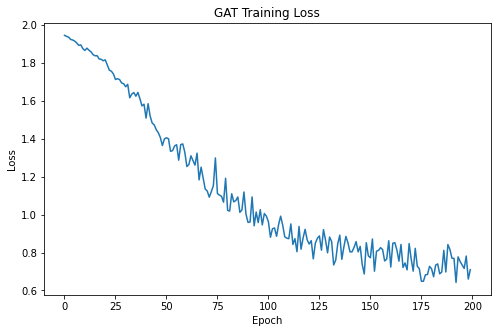

In [33]:
plt.figure(figsize=(8,5))

plt.plot(gat_losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAT Training Loss")

plt.show()

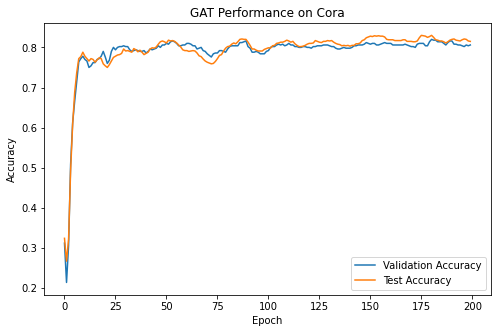

In [34]:
plt.figure(figsize=(8,5))

plt.plot(gat_val_accuracies, label="Validation Accuracy")
plt.plot(gat_test_accuracies, label="Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("GAT Performance on Cora")

plt.legend()

plt.show()

In [35]:
best_gat_val_acc = 0
best_gat_test_acc = 0
best_gat_test_f1 = 0
best_gat_epoch = 0

num_epochs = 200
gat_losses = []
gat_val_accuracies = []
gat_test_accuracies = []

for epoch in range(1, num_epochs + 1):
    loss = train_gat()
    train_acc, val_acc, test_acc, test_f1 = evaluate_gat()

    gat_losses.append(loss)
    gat_val_accuracies.append(val_acc)
    gat_test_accuracies.append(test_acc)

    if val_acc > best_gat_val_acc:
        best_gat_val_acc = val_acc
        best_gat_test_acc = test_acc
        best_gat_test_f1 = test_f1
        best_gat_epoch = epoch

    if epoch % 20 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Loss {loss:.4f} | "
            f"Val Acc {val_acc:.4f} | "
            f"Test Acc {test_acc:.4f} | "
            f"Test F1 {test_f1:.4f}"
        )

print("\nBest GAT Results")
print(f"Best Epoch: {best_gat_epoch}")
print(f"Best Validation Accuracy: {best_gat_val_acc:.4f}")
print(f"Corresponding Test Accuracy: {best_gat_test_acc:.4f}")
print(f"Corresponding Test Macro F1-score: {best_gat_test_f1:.4f}")

Epoch 020 | Loss 0.7132 | Val Acc 0.7980 | Test Acc 0.8200 | Test F1 0.8132
Epoch 040 | Loss 0.6617 | Val Acc 0.7980 | Test Acc 0.8210 | Test F1 0.8119
Epoch 060 | Loss 0.7292 | Val Acc 0.7940 | Test Acc 0.8110 | Test F1 0.8072
Epoch 080 | Loss 0.6092 | Val Acc 0.8000 | Test Acc 0.8090 | Test F1 0.8011
Epoch 100 | Loss 0.6401 | Val Acc 0.7960 | Test Acc 0.8160 | Test F1 0.8072
Epoch 120 | Loss 0.6750 | Val Acc 0.7960 | Test Acc 0.8060 | Test F1 0.8012
Epoch 140 | Loss 0.6124 | Val Acc 0.8000 | Test Acc 0.8230 | Test F1 0.8135
Epoch 160 | Loss 0.6510 | Val Acc 0.7980 | Test Acc 0.8090 | Test F1 0.8016
Epoch 180 | Loss 0.6450 | Val Acc 0.8000 | Test Acc 0.8140 | Test F1 0.8077
Epoch 200 | Loss 0.6024 | Val Acc 0.8000 | Test Acc 0.8110 | Test F1 0.8041

Best GAT Results
Best Epoch: 127
Best Validation Accuracy: 0.8120
Corresponding Test Accuracy: 0.8310
Corresponding Test Macro F1-score: 0.8198


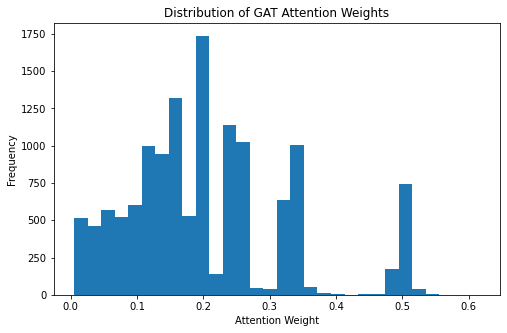

In [36]:
gat_model.eval()

with torch.no_grad():
    x_dropout = F.dropout(data.x, p=0.6, training=False)
    _, (edge_index_att, att_weights) = gat_model.gat1(
        x_dropout,
        data.edge_index,
        return_attention_weights=True
    )

att_weights_mean = att_weights.mean(dim=1).cpu().numpy()

plt.figure(figsize=(8,5))
plt.hist(att_weights_mean, bins=30)
plt.xlabel("Attention Weight")
plt.ylabel("Frequency")
plt.title("Distribution of GAT Attention Weights")
plt.show()

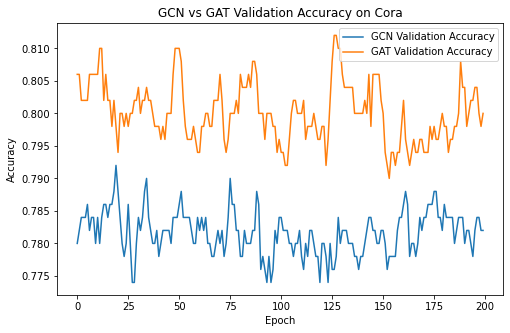

In [38]:
plt.figure(figsize=(8,5))
plt.plot(val_accuracies, label="GCN Validation Accuracy")
plt.plot(gat_val_accuracies, label="GAT Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("GCN vs GAT Validation Accuracy on Cora")
plt.legend()
plt.show()

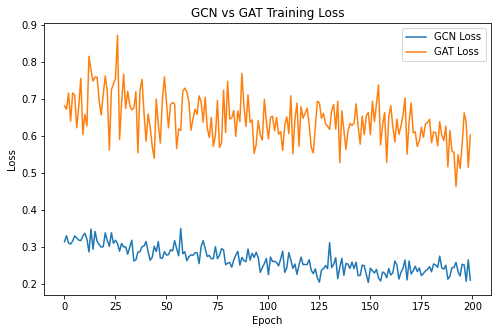

In [39]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="GCN Loss")
plt.plot(gat_losses, label="GAT Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GCN vs GAT Training Loss")

plt.legend()

plt.show()

In [40]:
print("Final Best Model Comparison on Cora")
print(f"GCN Best Epoch: {best_gcn_epoch}")
print(f"GCN Best Validation Accuracy: {best_gcn_val_acc:.4f}")
print(f"GCN Corresponding Test Accuracy: {best_gcn_test_acc:.4f}")
print(f"GCN Corresponding Test Macro F1-score: {best_gcn_test_f1:.4f}")
print()
print(f"GAT Best Epoch: {best_gat_epoch}")
print(f"GAT Best Validation Accuracy: {best_gat_val_acc:.4f}")
print(f"GAT Corresponding Test Accuracy: {best_gat_test_acc:.4f}")
print(f"GAT Corresponding Test Macro F1-score: {best_gat_test_f1:.4f}")

Final Best Model Comparison on Cora
GCN Best Epoch: 20
GCN Best Validation Accuracy: 0.7920
GCN Corresponding Test Accuracy: 0.8020
GCN Corresponding Test Macro F1-score: 0.7910

GAT Best Epoch: 127
GAT Best Validation Accuracy: 0.8120
GAT Corresponding Test Accuracy: 0.8310
GAT Corresponding Test Macro F1-score: 0.8198


In [41]:
results = {
    "Model": ["GCN", "GAT"],
    "Validation Accuracy": [best_gcn_val_acc, best_gat_val_acc],
    "Test Accuracy": [best_gcn_test_acc, best_gat_test_acc],
    "Test Macro F1": [best_gcn_test_f1, best_gat_test_f1]
}

import pandas as pd
results_df = pd.DataFrame(results)
print(results_df)

  Model  Validation Accuracy  Test Accuracy  Test Macro F1
0   GCN                0.792          0.802       0.790969
1   GAT                0.812          0.831       0.819784


## OGBN-Arxiv additional experiment

In [42]:
!pip install ogb

In [57]:
from ogb.nodeproppred import PygNodePropPredDataset, Evaluator

In [68]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import random
import pandas as pd

from torch_geometric.nn import GCNConv, GATConv
from torch_geometric.data.data import Data, DataEdgeAttr, DataTensorAttr
from torch_geometric.data.storage import BaseStorage, EdgeStorage, GlobalStorage, NodeStorage
from ogb.nodeproppred import PygNodePropPredDataset, Evaluator

In [69]:
# PyTorch 2.6+ safe globals fix for PyG/OGB cached datasets
torch.serialization.add_safe_globals([
    Data,
    DataEdgeAttr,
    DataTensorAttr,
    BaseStorage,
    NodeStorage,
    EdgeStorage,
    GlobalStorage,
])

In [70]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

set_seed(42)

In [71]:
dataset_arxiv = PygNodePropPredDataset(name="ogbn-arxiv")
data_arxiv = dataset_arxiv[0]

print(dataset_arxiv)
print(data_arxiv)
print("Nodes:", data_arxiv.num_nodes)
print("Edges:", data_arxiv.num_edges)
print("Features:", data_arxiv.x.shape)
print("Classes:", dataset_arxiv.num_classes)

PygNodePropPredDataset()
Data(num_nodes=169343, edge_index=[2, 1166243], x=[169343, 128], node_year=[169343, 1], y=[169343, 1])
Nodes: 169343
Edges: 1166243
Features: torch.Size([169343, 128])
Classes: 40


In [72]:
split_idx = dataset_arxiv.get_idx_split()

train_idx = split_idx["train"]
valid_idx = split_idx["valid"]
test_idx = split_idx["test"]

print("Train nodes:", train_idx.shape[0])
print("Validation nodes:", valid_idx.shape[0])
print("Test nodes:", test_idx.shape[0])

Train nodes: 90941
Validation nodes: 29799
Test nodes: 48603


In [73]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

data_arxiv = data_arxiv.to(device)
train_idx = train_idx.to(device)
valid_idx = valid_idx.to(device)
test_idx = test_idx.to(device)

criterion = torch.nn.CrossEntropyLoss()
evaluator = Evaluator(name="ogbn-arxiv")

Using device: cpu


## GCN on OGBN-Arxiv 

In [74]:
class ArxivGCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

In [75]:
arxiv_gcn = ArxivGCN(
    in_channels=data_arxiv.x.shape[1],
    hidden_channels=128,
    out_channels=dataset_arxiv.num_classes
).to(device)

arxiv_gcn_optimizer = torch.optim.Adam(
    arxiv_gcn.parameters(),
    lr=0.01,
    weight_decay=5e-4
)

In [76]:
def train_arxiv_gcn():
    arxiv_gcn.train()
    arxiv_gcn_optimizer.zero_grad()

    out = arxiv_gcn(data_arxiv.x, data_arxiv.edge_index)
    loss = criterion(out[train_idx], data_arxiv.y[train_idx].squeeze())

    loss.backward()
    arxiv_gcn_optimizer.step()
    return loss.item()

In [77]:
@torch.no_grad()
def evaluate_arxiv_gcn():
    arxiv_gcn.eval()

    out = arxiv_gcn(data_arxiv.x, data_arxiv.edge_index)
    pred = out.argmax(dim=-1, keepdim=True)

    train_acc = evaluator.eval({
        "y_true": data_arxiv.y[train_idx],
        "y_pred": pred[train_idx],
    })["acc"]

    valid_acc = evaluator.eval({
        "y_true": data_arxiv.y[valid_idx],
        "y_pred": pred[valid_idx],
    })["acc"]

    test_acc = evaluator.eval({
        "y_true": data_arxiv.y[test_idx],
        "y_pred": pred[test_idx],
    })["acc"]

    return train_acc, valid_acc, test_acc

In [78]:
num_epochs = 100

arxiv_gcn_losses = []
arxiv_gcn_train_accs = []
arxiv_gcn_val_accs = []
arxiv_gcn_test_accs = []

best_arxiv_valid_acc = 0
best_arxiv_test_acc = 0
best_arxiv_epoch = 0

for epoch in range(1, num_epochs + 1):
    loss = train_arxiv_gcn()
    train_acc, valid_acc, test_acc = evaluate_arxiv_gcn()

    arxiv_gcn_losses.append(loss)
    arxiv_gcn_train_accs.append(train_acc)
    arxiv_gcn_val_accs.append(valid_acc)
    arxiv_gcn_test_accs.append(test_acc)

    if valid_acc > best_arxiv_valid_acc:
        best_arxiv_valid_acc = valid_acc
        best_arxiv_test_acc = test_acc
        best_arxiv_epoch = epoch

    if epoch % 10 == 0:
        print(
            f"GCN Epoch {epoch:03d} | "
            f"Loss {loss:.4f} | "
            f"Train Acc {train_acc:.4f} | "
            f"Val Acc {valid_acc:.4f} | "
            f"Test Acc {test_acc:.4f}"
        )

print("\nBest OGBN-Arxiv GCN Results")
print(f"Best Epoch: {best_arxiv_epoch}")
print(f"Best Validation Accuracy: {best_arxiv_valid_acc:.4f}")
print(f"Corresponding Test Accuracy: {best_arxiv_test_acc:.4f}")

GCN Epoch 010 | Loss 2.7714 | Train Acc 0.3345 | Val Acc 0.3821 | Test Acc 0.3709
GCN Epoch 020 | Loss 2.2890 | Train Acc 0.4561 | Val Acc 0.4703 | Test Acc 0.4127
GCN Epoch 030 | Loss 1.9998 | Train Acc 0.5083 | Val Acc 0.5120 | Test Acc 0.4513
GCN Epoch 040 | Loss 1.8290 | Train Acc 0.5377 | Val Acc 0.5313 | Test Acc 0.4686
GCN Epoch 050 | Loss 1.7321 | Train Acc 0.5557 | Val Acc 0.5450 | Test Acc 0.4842
GCN Epoch 060 | Loss 1.6806 | Train Acc 0.5660 | Val Acc 0.5551 | Test Acc 0.4943
GCN Epoch 070 | Loss 1.6446 | Train Acc 0.5751 | Val Acc 0.5625 | Test Acc 0.4992
GCN Epoch 080 | Loss 1.6139 | Train Acc 0.5811 | Val Acc 0.5693 | Test Acc 0.5056
GCN Epoch 090 | Loss 1.5980 | Train Acc 0.5857 | Val Acc 0.5709 | Test Acc 0.5084
GCN Epoch 100 | Loss 1.5789 | Train Acc 0.5889 | Val Acc 0.5745 | Test Acc 0.5121

Best OGBN-Arxiv GCN Results
Best Epoch: 100
Best Validation Accuracy: 0.5745
Corresponding Test Accuracy: 0.5121


## GAT on OGBN-Arxiv 

In [79]:
class ArxivGAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=4):
        super().__init__()

        self.gat1 = GATConv(
            in_channels,
            hidden_channels,
            heads=heads,
            dropout=0.6
        )

        self.gat2 = GATConv(
            hidden_channels * heads,
            out_channels,
            heads=1,
            concat=False,
            dropout=0.6
        )

    def forward(self, x, edge_index):
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.gat1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.gat2(x, edge_index)
        return x

In [80]:
arxiv_gat = ArxivGAT(
    in_channels=data_arxiv.x.shape[1],
    hidden_channels=64,
    out_channels=dataset_arxiv.num_classes,
    heads=4
).to(device)

arxiv_gat_optimizer = torch.optim.Adam(
    arxiv_gat.parameters(),
    lr=0.005,
    weight_decay=5e-4
)

In [81]:
def train_arxiv_gat():
    arxiv_gat.train()
    arxiv_gat_optimizer.zero_grad()

    out = arxiv_gat(data_arxiv.x, data_arxiv.edge_index)
    loss = criterion(out[train_idx], data_arxiv.y[train_idx].squeeze())

    loss.backward()
    arxiv_gat_optimizer.step()
    return loss.item()

In [82]:
@torch.no_grad()
def evaluate_arxiv_gat():
    arxiv_gat.eval()

    out = arxiv_gat(data_arxiv.x, data_arxiv.edge_index)
    pred = out.argmax(dim=-1, keepdim=True)

    train_acc = evaluator.eval({
        "y_true": data_arxiv.y[train_idx],
        "y_pred": pred[train_idx],
    })["acc"]

    valid_acc = evaluator.eval({
        "y_true": data_arxiv.y[valid_idx],
        "y_pred": pred[valid_idx],
    })["acc"]

    test_acc = evaluator.eval({
        "y_true": data_arxiv.y[test_idx],
        "y_pred": pred[test_idx],
    })["acc"]

    return train_acc, valid_acc, test_acc

In [83]:
num_epochs = 100

arxiv_gat_losses = []
arxiv_gat_train_accs = []
arxiv_gat_val_accs = []
arxiv_gat_test_accs = []

best_arxiv_gat_valid_acc = 0
best_arxiv_gat_test_acc = 0
best_arxiv_gat_epoch = 0

for epoch in range(1, num_epochs + 1):
    loss = train_arxiv_gat()
    train_acc, valid_acc, test_acc = evaluate_arxiv_gat()

    arxiv_gat_losses.append(loss)
    arxiv_gat_train_accs.append(train_acc)
    arxiv_gat_val_accs.append(valid_acc)
    arxiv_gat_test_accs.append(test_acc)

    if valid_acc > best_arxiv_gat_valid_acc:
        best_arxiv_gat_valid_acc = valid_acc
        best_arxiv_gat_test_acc = test_acc
        best_arxiv_gat_epoch = epoch

    if epoch % 10 == 0:
        print(
            f"GAT Epoch {epoch:03d} | "
            f"Loss {loss:.4f} | "
            f"Train Acc {train_acc:.4f} | "
            f"Val Acc {valid_acc:.4f} | "
            f"Test Acc {test_acc:.4f}"
        )

print("\nBest OGBN-Arxiv GAT Results")
print(f"Best Epoch: {best_arxiv_gat_epoch}")
print(f"Best Validation Accuracy: {best_arxiv_gat_valid_acc:.4f}")
print(f"Corresponding Test Accuracy: {best_arxiv_gat_test_acc:.4f}")

GAT Epoch 010 | Loss 3.1688 | Train Acc 0.3185 | Val Acc 0.3405 | Test Acc 0.3257
GAT Epoch 020 | Loss 2.8899 | Train Acc 0.4326 | Val Acc 0.4516 | Test Acc 0.4235
GAT Epoch 030 | Loss 2.7479 | Train Acc 0.4813 | Val Acc 0.4969 | Test Acc 0.4555
GAT Epoch 040 | Loss 2.6734 | Train Acc 0.5044 | Val Acc 0.5207 | Test Acc 0.4795
GAT Epoch 050 | Loss 2.6360 | Train Acc 0.5203 | Val Acc 0.5336 | Test Acc 0.4907
GAT Epoch 060 | Loss 2.6172 | Train Acc 0.5229 | Val Acc 0.5338 | Test Acc 0.4931
GAT Epoch 070 | Loss 2.5837 | Train Acc 0.5254 | Val Acc 0.5370 | Test Acc 0.4964
GAT Epoch 080 | Loss 2.5609 | Train Acc 0.5250 | Val Acc 0.5373 | Test Acc 0.4988
GAT Epoch 090 | Loss 2.5561 | Train Acc 0.5265 | Val Acc 0.5379 | Test Acc 0.4956
GAT Epoch 100 | Loss 2.5450 | Train Acc 0.5258 | Val Acc 0.5360 | Test Acc 0.4946

Best OGBN-Arxiv GAT Results
Best Epoch: 85
Best Validation Accuracy: 0.5399
Corresponding Test Accuracy: 0.4972


In [84]:
print("OGBN-Arxiv Final Comparison\n")

print(f"GCN Best Validation Accuracy: {best_arxiv_valid_acc:.4f}")
print(f"GCN Corresponding Test Accuracy: {best_arxiv_test_acc:.4f}")

print()

print(f"GAT Best Validation Accuracy: {best_arxiv_gat_valid_acc:.4f}")
print(f"GAT Corresponding Test Accuracy: {best_arxiv_gat_test_acc:.4f}")

OGBN-Arxiv Final Comparison

GCN Best Validation Accuracy: 0.5745
GCN Corresponding Test Accuracy: 0.5121

GAT Best Validation Accuracy: 0.5399
GAT Corresponding Test Accuracy: 0.4972


In [85]:
results_arxiv = {
    "Dataset": ["OGBN-Arxiv", "OGBN-Arxiv"],
    "Model": ["GCN", "GAT"],
    "Validation Accuracy": [
        best_arxiv_valid_acc,
        best_arxiv_gat_valid_acc
    ],
    "Test Accuracy": [
        best_arxiv_test_acc,
        best_arxiv_gat_test_acc
    ]
}

results_arxiv_df = pd.DataFrame(results_arxiv)
print(results_arxiv_df)

      Dataset Model  Validation Accuracy  Test Accuracy
0  OGBN-Arxiv   GCN             0.574482       0.512067
1  OGBN-Arxiv   GAT             0.539884       0.497150


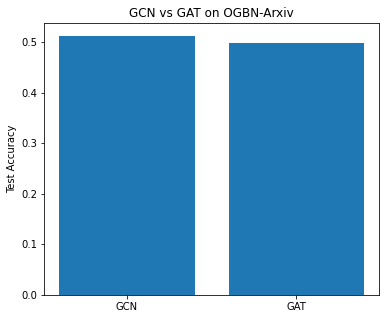

In [86]:
plt.figure(figsize=(6,5))
plt.bar(
    ["GCN", "GAT"],
    [best_arxiv_test_acc, best_arxiv_gat_test_acc]
)
plt.ylabel("Test Accuracy")
plt.title("GCN vs GAT on OGBN-Arxiv")
plt.show()

In [87]:
import pandas as pd

results_all = {
    "Dataset": ["Cora", "Cora", "OGBN-Arxiv", "OGBN-Arxiv"],
    "Model": ["GCN", "GAT", "GCN", "GAT"],
    "Validation Accuracy": [
        best_gcn_val_acc,
        best_gat_val_acc,
        best_arxiv_valid_acc,
        best_arxiv_gat_valid_acc
    ],
    "Test Accuracy": [
        best_gcn_test_acc,
        best_gat_test_acc,
        best_arxiv_test_acc,
        best_arxiv_gat_test_acc
    ],
    "Test Macro F1": [
        best_gcn_test_f1,
        best_gat_test_f1,
        None,
        None
    ]
}

results_all_df = pd.DataFrame(results_all)
print(results_all_df)

      Dataset Model  Validation Accuracy  Test Accuracy  Test Macro F1
0        Cora   GCN             0.792000       0.802000       0.790969
1        Cora   GAT             0.812000       0.831000       0.819784
2  OGBN-Arxiv   GCN             0.574482       0.512067            NaN
3  OGBN-Arxiv   GAT             0.539884       0.497150            NaN


In [88]:
print("FINAL MODEL COMPARISON\n")

print("Cora Results")
print(f"GCN - Validation Accuracy: {best_gcn_val_acc:.4f}")
print(f"GCN - Test Accuracy: {best_gcn_test_acc:.4f}")
print(f"GCN - Test Macro F1: {best_gcn_test_f1:.4f}")
print()

print(f"GAT - Validation Accuracy: {best_gat_val_acc:.4f}")
print(f"GAT - Test Accuracy: {best_gat_test_acc:.4f}")
print(f"GAT - Test Macro F1: {best_gat_test_f1:.4f}")
print()

print("OGBN-Arxiv Results")
print(f"GCN - Validation Accuracy: {best_arxiv_valid_acc:.4f}")
print(f"GCN - Test Accuracy: {best_arxiv_test_acc:.4f}")
print()

print(f"GAT - Validation Accuracy: {best_arxiv_gat_valid_acc:.4f}")
print(f"GAT - Test Accuracy: {best_arxiv_gat_test_acc:.4f}")

FINAL MODEL COMPARISON

Cora Results
GCN - Validation Accuracy: 0.7920
GCN - Test Accuracy: 0.8020
GCN - Test Macro F1: 0.7910

GAT - Validation Accuracy: 0.8120
GAT - Test Accuracy: 0.8310
GAT - Test Macro F1: 0.8198

OGBN-Arxiv Results
GCN - Validation Accuracy: 0.5745
GCN - Test Accuracy: 0.5121

GAT - Validation Accuracy: 0.5399
GAT - Test Accuracy: 0.4972


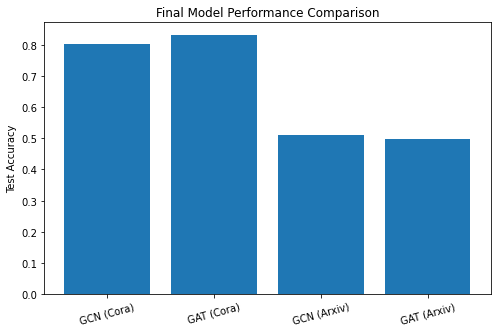

In [89]:
import matplotlib.pyplot as plt

models = ["GCN (Cora)", "GAT (Cora)", "GCN (Arxiv)", "GAT (Arxiv)"]
scores = [
    best_gcn_test_acc,
    best_gat_test_acc,
    best_arxiv_test_acc,
    best_arxiv_gat_test_acc
]

plt.figure(figsize=(8,5))
plt.bar(models, scores)
plt.ylabel("Test Accuracy")
plt.title("Final Model Performance Comparison")
plt.xticks(rotation=15)
plt.show()